# iscc — pipeline walkthrough

`iscc` simulates the whole journey from tumor biology to observed molecular data as **three composable stages**:

| Stage | CLI | Produces |
|---|---|---|
| 1. Growth | `isccsim` | a tumor's ground-truth per-cell state |
| 2. Sampling | `isccsample` | a biopsy / dissociation (subset of cells) |
| 3. Assay | `isccdata` | observed sequencing / spatial data |

This notebook runs all three with the **Python API** (and shows the equivalent CLI at the end). For deeper dives see `02_tumor_growth.ipynb` (explore the tumor) and `03_data_overview.ipynb` (explore the data).

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iscc

NB_DIR = os.getcwd()
CONFIG = os.path.join(NB_DIR, "example_config.yaml")
print("iscc from:", iscc.__file__)

iscc from: /Users/pedroferreira/projects/iscc/repo/src/iscc/__init__.py


## Stage 1 — grow a tumor

We build a spatial `GenotypeTumor` from a YAML config and grow it. The config sets the spatial mode, genome size, the CINner-style selection parameters, and per-cell-type rates.

In [2]:
from iscc.tumor.models import GenotypeTumor

tumor = GenotypeTumor(config=CONFIG, seed=2)
tumor.grow(n_steps=40, seed=2)
print(f"Tumor size: {tumor.get_tumor_size()} cells across {len(tumor.demes)} demes")

Tumor size: 9213 cells across 676 demes


### Visualise growth and spatial structure

The Muller plot shows clonal dynamics over time; the grid shows where clones and normal cells sit in space.

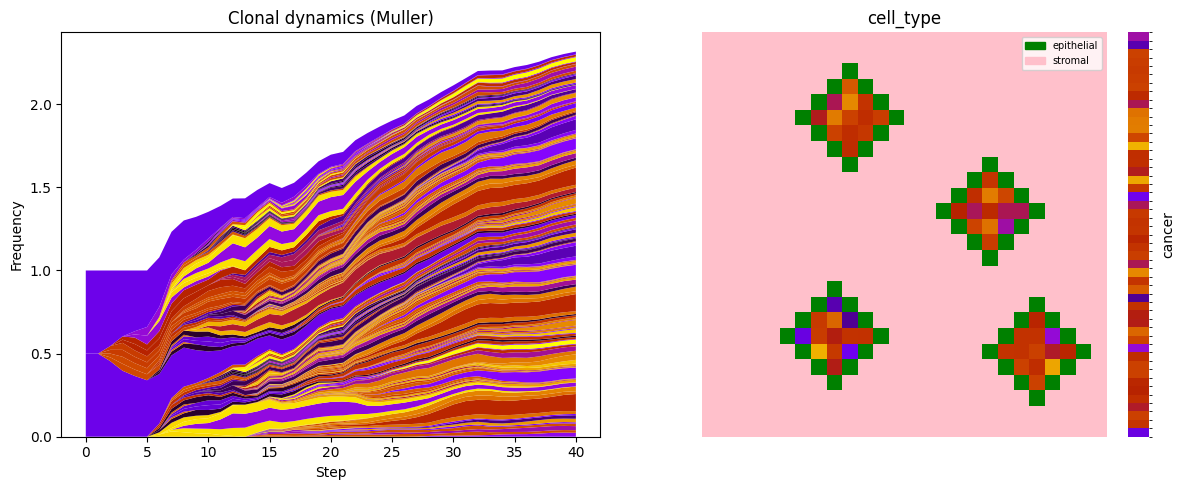

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tumor.plot_muller(ax=axes[0], min_freq=0.02)
axes[0].set_title("Clonal dynamics (Muller)")
tumor.plot_grid(ax=axes[1])
plt.tight_layout()

### The ground truth

The per-cell ground truth lives in `tumor.cell_data` (a dict of DataFrames, also written to `cell_data/` by `tumor.write(path)`). These matrices are what later stages sample and sequence.

In [4]:
cd = tumor.cell_data
print("cell_data matrices:", list(cd.keys()))
cd["cell_snv"].iloc[:5, :6]

cell_data matrices: ['cell_evo', 'cell_snv', 'cell_cnv', 'cell_exp', 'cell_crd', 'cell_type', 'cell_deme', 'cell_rna_vaf', 'cell_wgd', 'cell_gland']


,G_0_0,G_0_1,G_0_2,G_0_3,G_0_4,G_0_5
C0,0.0,0.0,0.0,0.0,0.0,0.0
C1,0.0,0.0,0.0,0.0,0.0,0.0
C2,0.0,0.0,0.0,0.0,0.0,0.0
C3,0.0,0.0,0.0,0.0,0.0,0.0
C4,0.0,0.0,0.0,0.0,0.0,0.0


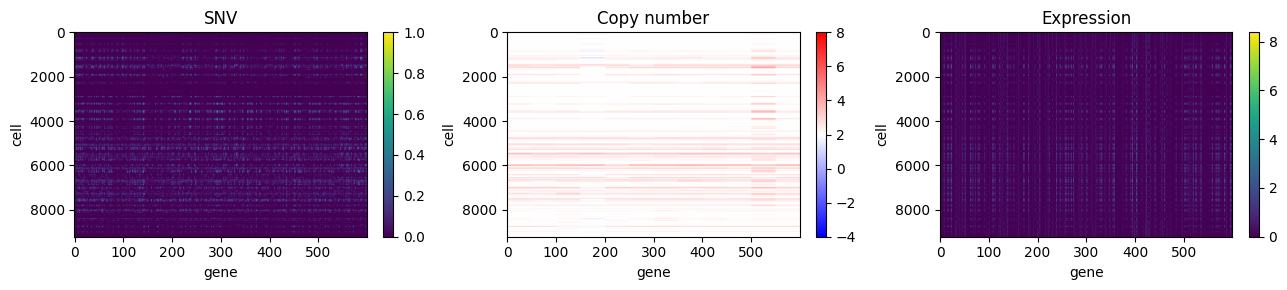

In [5]:
from iscc.tumor.viz import CNV_CMAP, cnv_norm
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, key, title in zip(axes, ["cell_snv", "cell_cnv", "cell_exp"], ["SNV", "Copy number", "Expression"]):
    if key == "cell_cnv":  # copy number: blue-white-red, white at diploid (2)
        im = ax.imshow(cd[key].values, aspect="auto", cmap=CNV_CMAP, norm=cnv_norm(cd[key].values))
    else:
        im = ax.imshow(cd[key].values, aspect="auto", cmap="viridis")
    ax.set_title(title); ax.set_xlabel("gene"); ax.set_ylabel("cell")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

## Stage 2 — sample the tumor (biopsy & dissociation)

`isccsample` captures a subset of cells while **preserving their ground truth**. Sampling is
spatially realistic: a `Biopsy` selects cells by geometry over the `cell_crd` grid — a **punch**
(disk), a **needle** core, **multi-region** disjoint disks (the substrate for multi-region
phylogenetics), or a **liquid** biopsy of circulating cells biased toward high-dispersal clones.
A `Dissociation` step can then apply cell-type-dependent recovery (composition bias). Here we take
a **punch** biopsy.

In [6]:
from iscc.sample.biopsy.biopsy import Biopsy

bx = Biopsy(cd, rng=np.random.default_rng(0))
chosen, region, geom = bx.sample(biopsy_type="punch")
sample = {k: df.loc[chosen] for k, df in cd.items()}
print(f"Punch biopsy: {len(chosen)} / {len(cd['cell_snv'])} cells")
print("geometry:", geom)

Punch biopsy: 1859 / 9213 cells
geometry: {'method': 'punch', 'center': [13.300336481059373, 12.582872028655162], 'radius': 6.25}


Text(0.5, 1.0, 'Punch biopsy footprint')

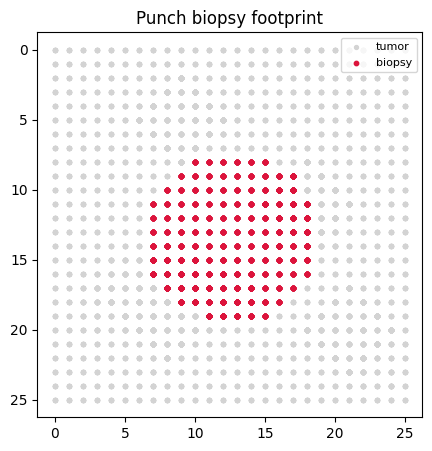

In [7]:
# The biopsy is a spatial region, not a random subset:
crd = cd["cell_crd"]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(crd["col"], crd["row"], s=8, c="lightgrey", label="tumor")
ax.scatter(crd.loc[chosen, "col"], crd.loc[chosen, "row"], s=10, c="crimson", label="biopsy")
ax.set_aspect("equal"); ax.invert_yaxis()
ax.legend(loc="upper right", fontsize=8); ax.set_title("Punch biopsy footprint")

## Stage 3 — run molecular assays

Each assay turns the sampled cells' ground truth into observed data. The assays live in `iscc.data`.

In [8]:
from iscc.data import scRNA, bulkDNA

sc_assay = scRNA(n_reads=3000, n_cells=300)
sc_assay.run(sample)
print("scRNA UMI matrix:", sc_assay.observed_counts.shape)
sc_assay.observed_counts.iloc[:5, :6]

scRNA UMI matrix: (300, 600)


,G_0_0,G_0_1,G_0_2,G_0_3,G_0_4,G_0_5
C4450,9,0,0,0,0,0
C5287,7,0,0,0,0,14
C3142,0,0,41,0,0,0
C4455,19,0,0,4,0,0
C2891,13,0,0,4,0,0


Text(0.5, 1.0, 'Bulk DNA VAF spectrum')

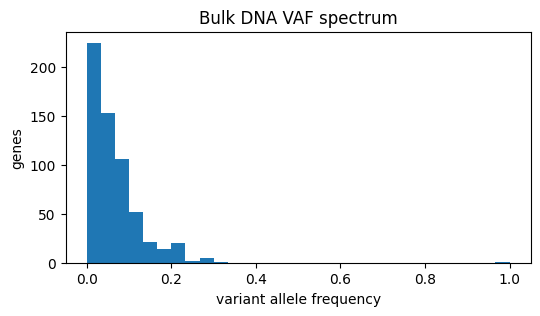

In [9]:
bd = bulkDNA(n_reads=20000, data_mode="counts", fpr=0.02, fnr=0.02)
bd.run(sample)
cov = bd.observed_data["coverage"].replace(0, np.nan)
vaf = (bd.observed_data["alt_counts"] / cov).dropna()
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(vaf, bins=30)
ax.set_xlabel("variant allele frequency"); ax.set_ylabel("genes")
ax.set_title("Bulk DNA VAF spectrum")

## The same pipeline from the command line

```bash
isccsim    --sim-config example_config.yaml -s 40 -o example_out/tumor
isccsample example_out/tumor --method biopsy --biopsy-type punch -o example_out/sample
isccdata   example_out/sample -a scrna --assay-config ../src/iscc/data/assayconfigs/scrna.yaml -o example_out/data_scrna
```

The shared dataset used by the other notebooks is produced once by `generate_example.py`.

**Next:** `02_tumor_growth.ipynb` (the tumor) · `03_data_overview.ipynb` (the data).